# MPro DiGress GINE Regression Notebook

This notebook builds a second GINE-based regression pipeline for SARS-CoV-2 main protease inhibitors. It reuses the original MPro train, validation, and test splits, but augments the training split with pseudo-labeled molecules generated by one or more DiGress runs.

## What this notebook covers

1. Environment setup and run configuration
2. Molecular graph construction from the original MPro `.smi` ligand files
3. Loading DiGress-generated molecules from one or more pseudo-label CSV files and appending them to the training split
4. Data-loader sanity checks
5. GINE model definition
6. Training with the fixed best hyperparameters loaded from `gine_best_hparams.json` and batch size `128`
7. Test-set prediction, regression metrics, and visualization

## Main outputs

Running the full workflow produces the following artifacts inside `notebooks/mpro_gine_regression/artifacts`:

- Cached graph tensors for faster reruns
- The best training checkpoint for the DiGress-augmented regressor
- A JSON file with training history
- A CSV file with test-set predictions

## Suggested execution order

1. Run the setup and graph-construction sections once per session.
2. Load and append the DiGress pseudo-labeled molecules to the training split.
3. Run the training section to save the best checkpoint.
4. Run the prediction and evaluation sections to inspect final performance.

## Environment

Open this notebook with the Python environment that already contains PyTorch, RDKit, scikit-learn, SciPy, pandas, and matplotlib.

```bash
conda activate digress
```

This section is split into two setup cells: one dedicated Imports cell and one runtime/helper cell.

This notebook expects the repository layout to remain unchanged, especially the `MPro-URV_Version2` directory and the ligand `.smi` files under `MPro-URV_Version2/Ligand/Ligand_SMI`.

A few practical notes before running the heavy cells:

- Graph generation is cached on disk, so the expensive preprocessing step only needs to run once unless the source data changes.
- This notebook consumes one or more pseudo-label CSV files, and by default uses `external_predictions_14Apr2026.csv` and `external_predictions_21Apr2026.csv` from `notebooks/mpro_gine_regression/artifacts`.
- Those pseudo-label CSVs should be generated first by running the external-molecule inference cell in `mpro_gine_pic50_regression.ipynb`.
- The tuned hyperparameters are loaded from `notebooks/mpro_gine_regression/artifacts/gine_best_hparams.json`, except the batch size is intentionally increased to `128` for this second training run.
- The ROC/AUC plot treats the regression output as an activity score using the threshold `pIC50 >= 6.0`.

### Imports

This cell contains all imports used throughout the notebook. It should be run before any other code cell in the notebook.

In [24]:
from __future__ import annotations

# Standard library imports
import copy
import json
import math
import random
from pathlib import Path
from typing import Any, Dict, List

# Third-party imports
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import display
from rdkit import Chem, RDLogger
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error, r2_score, roc_auc_score, roc_curve
from torch.utils.data import DataLoader, Dataset

### Runtime Setup and Display Helpers

This cell configures logging, plotting style, random seeds, device selection, and the small helper functions used to format notebook output.

In [25]:
# Keep the notebook output focused on useful information.
RDLogger.DisableLog('rdApp.*')
plt.style.use('seaborn-v0_8-whitegrid')

# Reproducibility setup
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Use a GPU when it is available, otherwise fall back to CPU.
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


def print_banner(title: str, width: int = 88, char: str = '=') -> None:
    """Print a clear section divider in notebook output."""
    rule = char * width
    print(f"\n{rule}\n{title}\n{rule}")


def display_key_values(title: str, values: Dict[str, Any]) -> None:
    """Display a small key-value table with a visible title."""
    print_banner(title)
    frame = pd.DataFrame({'value': pd.Series(values, dtype='object')})
    display(frame)


def display_metric_table(title: str, metrics: Dict[str, float], digits: int = 4) -> None:
    """Display metrics in a compact, consistently formatted table."""
    print_banner(title)
    metric_frame = pd.DataFrame(
        {
            'metric': list(metrics.keys()),
            'value': list(metrics.values()),
        }
    )
    display(metric_frame.round(digits))


display_key_values(
    'Runtime context',
    {
        'Random seed': SEED,
        'Device': str(DEVICE),
        'PyTorch version': torch.__version__,
        'NumPy version': np.__version__,
        'Pandas version': pd.__version__,
    },
)


Runtime context


,value
Random seed,42
Device,cpu
PyTorch version,2.8.0+cpu
NumPy version,1.26.4
Pandas version,2.3.1


### Paths and Run Configuration

This section resolves the repository root, defines the data and artifact locations, and centralizes the model and training hyperparameters for the DiGress-augmented regressor.

This notebook expects two kinds of existing inputs:

- `gine_best_hparams.json`, which provides the best hyperparameters from the first GINE run.
- One or more DiGress pseudo-label CSVs, which by default are `external_predictions_14Apr2026.csv` and `external_predictions_21Apr2026.csv` produced by `mpro_gine_pic50_regression.ipynb`.

The batch size is intentionally overridden to `128` in this second notebook so the architecture stays fixed while the training recipe changes as little as possible.

If changes to the run configuration are needed, this is the main cell to edit first. Typical adjustments include:

- `BATCH_SIZE` for memory usage
- `MAX_EPOCHS` and `PATIENCE` for optimization behavior
- `FORCE_REBUILD_GRAPHS` if cached graph tensors need to be regenerated
- `SELECTED_EXTERNAL_PSEUDOLABEL_SOURCES` if you want to use one or both pseudo-label CSVs
- `AVAILABLE_EXTERNAL_PSEUDOLABELS` if the DiGress prediction files are moved

In [26]:
def find_repo_root(start_path: Path) -> Path:
    """Walk upward until the project root containing the dataset is found."""
    current = start_path.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'MPro-URV_Version2').exists():
            return candidate
    raise FileNotFoundError('Could not locate the repository root containing MPro-URV_Version2.')


# Resolve the core project paths used throughout the notebook.
REPO_ROOT = find_repo_root(Path.cwd())
DATA_ROOT = REPO_ROOT / 'MPro-URV_Version2'
SMI_DIR = DATA_ROOT / 'Ligand' / 'Ligand_SMI'
TRAIN_CSV = DATA_ROOT / 'train.csv'
VAL_CSV = DATA_ROOT / 'val.csv'
TEST_CSV = DATA_ROOT / 'test.csv'

# Keep all notebook-generated files in one place.
ARTIFACT_DIR = REPO_ROOT / 'notebooks' / 'mpro_gine_regression' / 'artifacts'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
HPARAMS_PATH = ARTIFACT_DIR / 'gine_best_hparams.json'
AVAILABLE_EXTERNAL_PSEUDOLABELS = {
    '14Apr2026': ARTIFACT_DIR / 'external_predictions_14Apr2026.csv',
    '21Apr2026': ARTIFACT_DIR / 'external_predictions_21Apr2026.csv',
}
SELECTED_EXTERNAL_PSEUDOLABEL_SOURCES = ['14Apr2026', '21Apr2026']

if not SELECTED_EXTERNAL_PSEUDOLABEL_SOURCES:
    raise ValueError('Select at least one DiGress pseudo-label source before continuing.')

unknown_external_sources = sorted(
    set(SELECTED_EXTERNAL_PSEUDOLABEL_SOURCES).difference(AVAILABLE_EXTERNAL_PSEUDOLABELS)
    )
if unknown_external_sources:
    raise ValueError(
        f'Unknown DiGress pseudo-label source(s): {unknown_external_sources}. '
        f'Available sources: {sorted(AVAILABLE_EXTERNAL_PSEUDOLABELS)}'
    )

EXTERNAL_PSEUDOLABELS_PATHS = {
    source_label: AVAILABLE_EXTERNAL_PSEUDOLABELS[source_label]
    for source_label in SELECTED_EXTERNAL_PSEUDOLABEL_SOURCES
}
GRAPH_CACHE = ARTIFACT_DIR / 'mpro_graph_cache.pt'
CHECKPOINT_PATH = ARTIFACT_DIR / 'gine_digress_pic50_regressor.pt'
PREDICTIONS_PATH = ARTIFACT_DIR / 'digress_augmented_test_predictions.csv'
HISTORY_PATH = ARTIFACT_DIR / 'digress_augmented_training_history.json'

# Default fallback values before loading the tuned configuration.
DEFAULT_BATCH_SIZE = 32
DEFAULT_HIDDEN_DIM = 128
DEFAULT_NUM_LAYERS = 4
DEFAULT_DROPOUT = 0.15
DEFAULT_LEARNING_RATE = 1e-3
DEFAULT_WEIGHT_DECAY = 1e-4
DEFAULT_MAX_EPOCHS = 300
DEFAULT_PATIENCE = 40

# This notebook requires the best hyperparameters from the first GINE run.
if not HPARAMS_PATH.exists():
    raise FileNotFoundError(f'Best hyperparameters file not found at {HPARAMS_PATH}')

with HPARAMS_PATH.open('r', encoding='utf-8') as handle:
    hparams = json.load(handle)

# Reuse the tuned configuration and only increase the batch size for the second GNN.
BATCH_SIZE = 128
HIDDEN_DIM = int(hparams.get('hidden_dim', DEFAULT_HIDDEN_DIM))
NUM_LAYERS = int(hparams.get('num_layers', DEFAULT_NUM_LAYERS))
DROPOUT = float(hparams.get('dropout', DEFAULT_DROPOUT))
LEARNING_RATE = float(hparams.get('learning_rate', DEFAULT_LEARNING_RATE))
WEIGHT_DECAY = float(hparams.get('weight_decay', DEFAULT_WEIGHT_DECAY))
MAX_EPOCHS = int(hparams.get('max_epochs', DEFAULT_MAX_EPOCHS))
PATIENCE = int(hparams.get('patience', DEFAULT_PATIENCE))

ACTIVE_THRESHOLD = 6.0
FORCE_REBUILD_GRAPHS = False
LOSS_NAME = 'rmse'

BASE_MODEL_CONFIG = {
    'hidden_dim': HIDDEN_DIM,
    'num_layers': NUM_LAYERS,
    'dropout': DROPOUT,
}
BASE_TRAINING_CONFIG = {
    'batch_size': BATCH_SIZE,
    'learning_rate': LEARNING_RATE,
    'weight_decay': WEIGHT_DECAY,
    'max_epochs': MAX_EPOCHS,
    'patience': PATIENCE,
    'loss_name': LOSS_NAME,
}

resolved_paths = {
    'Repository root': REPO_ROOT,
    'Data root': DATA_ROOT,
    'SMILES directory': SMI_DIR,
    'Artifact directory': ARTIFACT_DIR,
    'Best hparams path': HPARAMS_PATH,
    'Checkpoint path': CHECKPOINT_PATH,
}
for source_label, csv_path in EXTERNAL_PSEUDOLABELS_PATHS.items():
    resolved_paths[f'DiGress pseudo-label CSV ({source_label})'] = csv_path

display_key_values('Resolved paths', resolved_paths)

print_banner('Fixed configuration')
display(
    pd.DataFrame(
        [
            {'group': 'model', 'name': key, 'value': value}
            for key, value in BASE_MODEL_CONFIG.items()
        ]
        + [
            {'group': 'training', 'name': key, 'value': value}
            for key, value in BASE_TRAINING_CONFIG.items()
        ]
        + [
            {'group': 'general', 'name': 'active_threshold', 'value': ACTIVE_THRESHOLD},
            {'group': 'general', 'name': 'force_rebuild_graphs', 'value': FORCE_REBUILD_GRAPHS},
            {
                'group': 'general',
                'name': 'selected_digress_sources',
                'value': ', '.join(SELECTED_EXTERNAL_PSEUDOLABEL_SOURCES),
            },
        ]
    )
)


Resolved paths


,value
Repository root,C:\Users\xaviv\URV\.MESIIA\TFM\repo\DiGressMPr...
Data root,C:\Users\xaviv\URV\.MESIIA\TFM\repo\DiGressMPr...
SMILES directory,C:\Users\xaviv\URV\.MESIIA\TFM\repo\DiGressMPr...
Artifact directory,C:\Users\xaviv\URV\.MESIIA\TFM\repo\DiGressMPr...
Best hparams path,C:\Users\xaviv\URV\.MESIIA\TFM\repo\DiGressMPr...
Checkpoint path,C:\Users\xaviv\URV\.MESIIA\TFM\repo\DiGressMPr...
DiGress pseudo-label CSV (14Apr2026),C:\Users\xaviv\URV\.MESIIA\TFM\repo\DiGressMPr...
DiGress pseudo-label CSV (21Apr2026),C:\Users\xaviv\URV\.MESIIA\TFM\repo\DiGressMPr...



Fixed configuration


,group,name,value
0,model,hidden_dim,256
1,model,num_layers,6
2,model,dropout,0.05
3,training,batch_size,128
4,training,learning_rate,0.0005
5,training,weight_decay,0.00001
6,training,max_epochs,300
7,training,patience,50
8,training,loss_name,rmse
9,general,active_threshold,6.0


## Graph Definition

Each ligand is converted into a graph where atoms are nodes and bonds are represented as bidirectional edges. The `.smi` file is treated as the source of truth for each molecule string.

### Feature design

- Node features encode atom identity, hybridization, degree, hydrogen count, formal charge, aromaticity, ring membership, and a scaled atomic mass.
- Edge features encode bond type, stereochemistry, conjugation, and ring membership.

The next code cell handles four jobs in one place:

1. Define the node and edge featurization functions.
2. Read the train, validation, and test splits.
3. Build graph objects or reload them from cache.
4. Compute the feature dimensions and target normalization statistics used later by the model.

In [27]:
# Common atom and bond categories used by the featurizers.
ATOM_TYPES = ['C', 'N', 'O', 'F', 'S', 'Cl', 'Br', 'I', 'P', 'H', 'Other']
ATOM_TO_INDEX = {symbol: idx for idx, symbol in enumerate(ATOM_TYPES)}
HYBRIDIZATION_TYPES = [
    Chem.rdchem.HybridizationType.SP,
    Chem.rdchem.HybridizationType.SP2,
    Chem.rdchem.HybridizationType.SP3,
    Chem.rdchem.HybridizationType.SP3D,
    Chem.rdchem.HybridizationType.SP3D2,
]
BOND_TYPES = [
    Chem.rdchem.BondType.SINGLE,
    Chem.rdchem.BondType.DOUBLE,
    Chem.rdchem.BondType.TRIPLE,
    Chem.rdchem.BondType.AROMATIC,
]
STEREO_TYPES = [
    Chem.rdchem.BondStereo.STEREONONE,
    Chem.rdchem.BondStereo.STEREOANY,
    Chem.rdchem.BondStereo.STEREOZ,
    Chem.rdchem.BondStereo.STEREOE,
]


def one_hot_with_unknown(value, choices):
    """Encode a value with an additional bucket for unseen categories."""
    vector = [0.0] * (len(choices) + 1)
    try:
        vector[choices.index(value)] = 1.0
    except ValueError:
        vector[-1] = 1.0
    return vector


def atom_features(atom: Chem.Atom) -> torch.Tensor:
    """Convert one RDKit atom into a fixed-length feature vector."""
    symbol = atom.GetSymbol()
    symbol = symbol if symbol in ATOM_TO_INDEX else 'Other'

    feature_vector = []
    feature_vector.extend(one_hot_with_unknown(symbol, ATOM_TYPES[:-1]))
    feature_vector.extend(one_hot_with_unknown(atom.GetHybridization(), HYBRIDIZATION_TYPES))
    feature_vector.extend(one_hot_with_unknown(atom.GetDegree(), [0, 1, 2, 3, 4, 5]))
    feature_vector.extend(one_hot_with_unknown(atom.GetTotalNumHs(), [0, 1, 2, 3, 4]))
    feature_vector.extend(one_hot_with_unknown(atom.GetFormalCharge(), [-2, -1, 0, 1, 2]))
    feature_vector.extend(
        [
            float(atom.GetIsAromatic()),
            float(atom.IsInRing()),
            float(atom.GetMass() / 200.0),
        ]
    )
    return torch.tensor(feature_vector, dtype=torch.float32)


def bond_features(bond: Chem.Bond) -> torch.Tensor:
    """Convert one RDKit bond into a fixed-length feature vector."""
    feature_vector = []
    feature_vector.extend(one_hot_with_unknown(bond.GetBondType(), BOND_TYPES))
    feature_vector.extend(one_hot_with_unknown(bond.GetStereo(), STEREO_TYPES))
    feature_vector.extend(
        [
            float(bond.GetIsConjugated()),
            float(bond.IsInRing()),
        ]
    )
    return torch.tensor(feature_vector, dtype=torch.float32)


EXAMPLE_BOND = Chem.MolFromSmiles('CC').GetBondWithIdx(0)
BOND_FEATURE_DIM = bond_features(EXAMPLE_BOND).numel()

display_key_values(
    'Feature encoding setup',
    {
        'Atom categories': len(ATOM_TYPES),
        'Hybridization categories': len(HYBRIDIZATION_TYPES),
        'Bond categories': len(BOND_TYPES),
        'Stereo categories': len(STEREO_TYPES),
        'Edge feature dimension': BOND_FEATURE_DIM,
    },
)


Feature encoding setup


,value
Atom categories,11
Hybridization categories,5
Bond categories,4
Stereo categories,4
Edge feature dimension,12


### Split Files and Graph Builders

These functions read the molecular strings from the `.smi` files, convert one molecule into graph tensors, and build or reload the cache for the train, validation, and test splits.

In [28]:
def read_smiles_from_smi(pdb_id: str, smi_dir: Path) -> str:
    """Load the first SMILES entry associated with a PDB identifier."""
    matches = sorted(smi_dir.glob(f'{pdb_id}_*.smi'))
    if not matches:
        raise FileNotFoundError(f'No .smi file found for {pdb_id}')

    with matches[0].open('r', encoding='utf-8') as handle:
        line = handle.readline().strip()

    if not line:
        raise ValueError(f'Empty .smi file for {pdb_id}: {matches[0]}')

    return line.split()[0]


def molecule_to_graph(smiles: str, target: float, pdb_id: str) -> Dict[str, torch.Tensor]:
    """Build the graph tensors needed by the GINE model for one molecule."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(f'RDKit could not parse SMILES for {pdb_id}: {smiles}')

    node_features = torch.stack([atom_features(atom) for atom in mol.GetAtoms()])

    edge_pairs = []
    edge_features = []
    for bond in mol.GetBonds():
        start = bond.GetBeginAtomIdx()
        end = bond.GetEndAtomIdx()
        features = bond_features(bond)

        # Store both bond directions so message passing works on directed edges.
        edge_pairs.extend([[start, end], [end, start]])
        edge_features.extend([features, features.clone()])

    if edge_pairs:
        edge_index = torch.tensor(edge_pairs, dtype=torch.long).t().contiguous()
        edge_attr = torch.stack(edge_features)
    else:
        edge_index = torch.empty((2, 0), dtype=torch.long)
        edge_attr = torch.empty((0, BOND_FEATURE_DIM), dtype=torch.float32)

    return {
        'x': node_features,
        'edge_index': edge_index,
        'edge_attr': edge_attr,
        'y': torch.tensor(float(target), dtype=torch.float32),
        'pdb_id': pdb_id,
        'smiles': smiles,
    }


def load_split_dataframe(csv_path: Path, smi_dir: Path) -> pd.DataFrame:
    """Read a split CSV and attach the SMILES string loaded from disk."""
    frame = pd.read_csv(csv_path).copy()
    frame['smiles_from_smi'] = frame['PDB_ID'].map(lambda pdb_id: read_smiles_from_smi(pdb_id, smi_dir))
    return frame


def build_graph_cache(force_rebuild: bool = False) -> Dict[str, List[Dict[str, torch.Tensor]]]:
    """Load cached graphs when available, otherwise rebuild them from the raw files."""
    if GRAPH_CACHE.exists() and not force_rebuild:
        print_banner('Graph cache')
        print(f'Loading cached graphs from: {GRAPH_CACHE}')
        return torch.load(GRAPH_CACHE, weights_only=False)

    print_banner('Graph cache')
    print('Cache miss or forced rebuild detected. Recomputing graph tensors...')

    split_frames = {
        'train': load_split_dataframe(TRAIN_CSV, SMI_DIR),
        'val': load_split_dataframe(VAL_CSV, SMI_DIR),
        'test': load_split_dataframe(TEST_CSV, SMI_DIR),
    }

    cache = {}
    for split_name, frame in split_frames.items():
        graphs = []
        for row in frame.itertuples(index=False):
            graphs.append(molecule_to_graph(row.smiles_from_smi, row.pIC50, row.PDB_ID))
        cache[split_name] = graphs

    torch.save(cache, GRAPH_CACHE)
    print(f'Graph cache saved to: {GRAPH_CACHE}')
    return cache

### Dataset and Batching Utilities

These helpers wrap the graph dictionaries into a PyTorch dataset, merge variable-size graphs into a single mini-batch, and move tensor fields onto the active device.

### Where target normalization happens

The target normalization used for training is applied inside the dataset object, not inside the model itself.

- `TARGET_MEAN` and `TARGET_STD` are computed from the training split only.
- Each sample returns a normalized target in `y` and the original target in `y_raw`.
- The normalized target is used for the optimization loss.
- The raw target is kept so evaluation can still report metrics in the original `pIC50` scale.

In [29]:
class MoleculeGraphDataset(Dataset):
    """Simple dataset wrapper with optional target normalization."""

    def __init__(self, graphs: List[Dict[str, torch.Tensor]], y_mean: float | None = None, y_std: float | None = None):
        self.graphs = graphs
        self.y_mean = y_mean
        self.y_std = y_std

    def __len__(self) -> int:
        return len(self.graphs)

    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        item = self.graphs[idx]
        y = item['y']
        if self.y_mean is not None and self.y_std is not None:
            # Normalize targets with training-split statistics before optimization.
            y = (y - self.y_mean) / self.y_std

        return {
            'x': item['x'],
            'edge_index': item['edge_index'],
            'edge_attr': item['edge_attr'],
            'y': y,
            # Keep the original target so metrics can be reported on the real pIC50 scale.
            'y_raw': item['y'],
            'pdb_id': item['pdb_id'],
            'smiles': item['smiles'],
        }


def collate_graphs(batch: List[Dict[str, torch.Tensor]]) -> Dict[str, torch.Tensor]:
    """Merge a list of variable-sized molecular graphs into one mini-batch."""
    x_parts = []
    edge_index_parts = []
    edge_attr_parts = []
    batch_index = []
    targets = []
    raw_targets = []
    pdb_ids = []
    smiles = []
    node_offset = 0

    for graph_idx, item in enumerate(batch):
        num_nodes = item['x'].size(0)
        x_parts.append(item['x'])
        batch_index.append(torch.full((num_nodes,), graph_idx, dtype=torch.long))
        targets.append(item['y'].view(1))
        raw_targets.append(item['y_raw'].view(1))
        pdb_ids.append(item['pdb_id'])
        smiles.append(item['smiles'])

        if item['edge_index'].numel() > 0:
            edge_index_parts.append(item['edge_index'] + node_offset)
            edge_attr_parts.append(item['edge_attr'])

        node_offset += num_nodes

    edge_dim = batch[0]['edge_attr'].size(-1) if batch[0]['edge_attr'].ndim == 2 else 0

    return {
        'x': torch.cat(x_parts, dim=0),
        'edge_index': torch.cat(edge_index_parts, dim=1) if edge_index_parts else torch.empty((2, 0), dtype=torch.long),
        'edge_attr': torch.cat(edge_attr_parts, dim=0) if edge_attr_parts else torch.empty((0, edge_dim), dtype=torch.float32),
        'batch': torch.cat(batch_index, dim=0),
        'y': torch.cat(targets, dim=0),
        'y_raw': torch.cat(raw_targets, dim=0),
        'pdb_id': pdb_ids,
        'smiles': smiles,
    }


def move_batch_to_device(batch: Dict[str, torch.Tensor], device: torch.device) -> Dict[str, torch.Tensor]:
    """Move tensor entries of a batch to the selected device."""
    tensor_keys = {'x', 'edge_index', 'edge_attr', 'batch', 'y', 'y_raw'}
    return {key: value.to(device) if key in tensor_keys else value for key, value in batch.items()}

### Cache Loading, DiGress Augmentation, and Feature Statistics

This cell loads the original cached MPro graphs, reads one or more DiGress pseudo-label CSV files, merges them into a single pseudo-labeled set, converts those generated molecules into graphs, and appends them to the training split only.

If the same SMILES appears in more than one selected pseudo-label CSV, the notebook collapses those duplicates before augmentation so the same generated molecule does not get over-weighted during training.

Validation and test splits remain unchanged so the second GNN can be compared directly against the first one.

### Why these statistics matter

`TARGET_MEAN` and `TARGET_STD` are computed from the augmented training split only. Those two values are then reused for train, validation, and test samples so every split is transformed with the same reference scale.

That keeps normalization consistent while still preventing any information leakage from the validation or test targets into training-time preprocessing.

In [30]:
def load_digress_pseudolabeled_graphs(
    csv_paths: Dict[str, Path],
) -> tuple[List[Dict[str, torch.Tensor]], pd.DataFrame]:
    """Load one or more pseudo-labeled DiGress CSVs and convert them into graph dictionaries."""
    missing_paths = [
        f'{source_label}: {csv_path}'
        for source_label, csv_path in csv_paths.items()
        if not csv_path.exists()
    ]
    if missing_paths:
        raise FileNotFoundError(
            'Missing DiGress pseudo-label CSV file(s). Run the external inference cell in '
            'mpro_gine_pic50_regression.ipynb first, or update AVAILABLE_EXTERNAL_PSEUDOLABELS.\n'
            + '\n'.join(missing_paths)
        )

    source_frames = []
    source_summaries = []
    required_columns = {'SMILES', 'pIC50'}

    for source_label, csv_path in csv_paths.items():
        frame = pd.read_csv(csv_path).copy()
        missing_columns = required_columns.difference(frame.columns)
        if missing_columns:
            raise ValueError(
                f'Missing required columns in {csv_path}: {sorted(missing_columns)}'
            )

        rows_loaded = len(frame)
        frame = frame[['SMILES', 'pIC50']].copy()
        frame['SMILES'] = frame['SMILES'].fillna('').astype(str).str.strip()
        frame['pIC50'] = pd.to_numeric(frame['pIC50'], errors='coerce')
        frame = frame.loc[frame['SMILES'].ne('')].dropna(subset=['pIC50']).copy()
        frame['source'] = source_label

        source_frames.append(frame)
        source_summaries.append(
            {
                'source': source_label,
                'csv_path': str(csv_path),
                'rows_loaded': rows_loaded,
                'usable_rows': len(frame),
                'unique_smiles': int(frame['SMILES'].nunique()),
            }
        )

    combined_frame = pd.concat(source_frames, ignore_index=True)
    duplicate_rows = int(combined_frame.duplicated(subset=['SMILES']).sum())
    if duplicate_rows:
        print(
            'Collapsing '
            f'{duplicate_rows} duplicate pseudo-label rows that appear across the selected DiGress sources.'
        )

    merged_frame = (
        combined_frame.groupby('SMILES', as_index=False)
        .agg(
            pIC50=('pIC50', 'mean'),
            source=('source', lambda values: '|'.join(sorted(set(values)))),
        )
        .reset_index(drop=True)
    )

    graphs = []
    failed_smiles = []

    for row_idx, row in merged_frame.iterrows():
        smiles = str(row['SMILES']).strip()
        if not smiles:
            continue

        try:
            graph = molecule_to_graph(
                smiles,
                target=float(row['pIC50']),
                pdb_id=f"digress_{row['source']}_{row_idx:05d}",
            )
            graphs.append(graph)
        except ValueError:
            failed_smiles.append(smiles)

    if failed_smiles:
        print(
            f'Warning: {len(failed_smiles)} DiGress SMILES could not be parsed and were skipped.'
        )

    summary_frame = pd.DataFrame(source_summaries)
    summary_frame = pd.concat(
        [
            summary_frame,
            pd.DataFrame(
                [
                    {
                        'source': 'combined',
                        'csv_path': '; '.join(str(csv_path) for csv_path in csv_paths.values()),
                        'rows_loaded': len(combined_frame),
                        'usable_rows': len(merged_frame),
                        'unique_smiles': int(merged_frame['SMILES'].nunique()),
                        'duplicate_smiles_collapsed': duplicate_rows,
                        'failed_smiles': len(failed_smiles),
                        'graphs_added': len(graphs),
                    }
                ]
            ),
        ],
        ignore_index=True,
    )

    return graphs, summary_frame


GRAPH_CACHE_CONTENT = build_graph_cache(force_rebuild=FORCE_REBUILD_GRAPHS)

# Keep the original supervised splits and augment only the training split with pseudo-labeled DiGress molecules.
ORIGINAL_TRAIN_GRAPHS = list(GRAPH_CACHE_CONTENT['train'])
DIGRESS_PSEUDOLABELED_GRAPHS, DIGRESS_PSEUDOLABEL_SOURCE_SUMMARY = load_digress_pseudolabeled_graphs(
    EXTERNAL_PSEUDOLABELS_PATHS
)
GRAPH_CACHE_CONTENT['train'] = ORIGINAL_TRAIN_GRAPHS + DIGRESS_PSEUDOLABELED_GRAPHS

# Graph dictionaries keep raw targets in graph['y']; the dataset wrapper handles normalization later.
train_targets_raw = np.array([graph['y'].item() for graph in GRAPH_CACHE_CONTENT['train']], dtype=np.float32)
TARGET_MEAN = float(train_targets_raw.mean())
TARGET_STD = float(train_targets_raw.std())
if TARGET_STD <= 1e-8:
    TARGET_STD = 1.0

NODE_DIM = int(GRAPH_CACHE_CONTENT['train'][0]['x'].shape[-1])
EDGE_DIM = int(GRAPH_CACHE_CONTENT['train'][0]['edge_attr'].shape[-1])

display_key_values(
    'Augmented graph statistics',
    {
        'Original train graphs': len(ORIGINAL_TRAIN_GRAPHS),
        'Appended DiGress graphs': len(DIGRESS_PSEUDOLABELED_GRAPHS),
        'Augmented train graphs': len(GRAPH_CACHE_CONTENT['train']),
        'Validation graphs': len(GRAPH_CACHE_CONTENT['val']),
        'Test graphs': len(GRAPH_CACHE_CONTENT['test']),
        'Node feature dimension': NODE_DIM,
        'Edge feature dimension': EDGE_DIM,
        'Training target mean': round(TARGET_MEAN, 4),
        'Training target std': round(TARGET_STD, 4),
    },
)

print_banner('DiGress pseudo-label source summary')
display(DIGRESS_PSEUDOLABEL_SOURCE_SUMMARY.fillna(''))


Graph cache
Loading cached graphs from: C:\Users\xaviv\URV\.MESIIA\TFM\repo\DiGressMProURV\notebooks\mpro_gine_regression\artifacts\mpro_graph_cache.pt
Collapsing 7 duplicate pseudo-label rows that appear across the selected DiGress sources.

Augmented graph statistics


,value
Original train graphs,210
Appended DiGress graphs,3575
Augmented train graphs,3785
Validation graphs,50
Test graphs,64
Node feature dimension,39
Edge feature dimension,12
Training target mean,5.4226
Training target std,0.6406



DiGress pseudo-label source summary


,source,csv_path,rows_loaded,usable_rows,unique_smiles,duplicate_smiles_collapsed,failed_smiles,graphs_added
0,14Apr2026,C:\Users\xaviv\URV\.MESIIA\TFM\repo\DiGressMPr...,1802,1802,1802,,,
1,21Apr2026,C:\Users\xaviv\URV\.MESIIA\TFM\repo\DiGressMPr...,1780,1780,1780,,,
2,combined,C:\Users\xaviv\URV\.MESIIA\TFM\repo\DiGressMPr...,3582,3575,3575,7.0,0.0,3575.0


### Split Overview

Before training, it is useful to inspect the three dataset splits at a glance. The next cell reports the number of samples and basic target statistics for the train, validation, and test partitions.

This is a quick sanity check for two things:

- The graph cache matches the expected split sizes.
- The target distributions are in a comparable numeric range across splits.

In [31]:
# Summarize split sizes and target distributions after augmenting the training split.
split_summary_rows = []
for split_name in ['train', 'val', 'test']:
    split_targets = np.array([graph['y'].item() for graph in GRAPH_CACHE_CONTENT[split_name]], dtype=np.float32)
    split_summary_rows.append(
        {
            'split': 'train_augmented' if split_name == 'train' else split_name,
            'n_samples': len(GRAPH_CACHE_CONTENT[split_name]),
            'pic50_mean': split_targets.mean(),
            'pic50_std': split_targets.std(),
            'pic50_min': split_targets.min(),
            'pic50_max': split_targets.max(),
            'notes': 'original train + DiGress pseudo-labels' if split_name == 'train' else 'original split',
        }
    )

split_summary = pd.DataFrame(split_summary_rows)
print_banner('Dataset split summary')
display(split_summary.round(3))


Dataset split summary


,split,n_samples,pic50_mean,pic50_std,pic50_min,pic50_max,notes
0,train_augmented,3785,5.423,0.641,4.018,8.569,original train + DiGress pseudo-labels
1,val,50,5.744,0.891,4.004,7.699,original split
2,test,64,5.896,0.796,4.013,8.000,original split


### Data Loaders and Batch Shape

This section wraps the cached graph objects into PyTorch datasets and data loaders. It then inspects one mini-batch to verify that the tensor shapes match what the GINE model expects.

The sanity check is useful because batching variable-size graphs is usually where indexing mistakes first show up.

In [32]:
def build_data_loaders(batch_size: int):
    """Create normalized datasets and data loaders for all splits."""
    train_dataset = MoleculeGraphDataset(GRAPH_CACHE_CONTENT['train'], y_mean=TARGET_MEAN, y_std=TARGET_STD)
    val_dataset = MoleculeGraphDataset(GRAPH_CACHE_CONTENT['val'], y_mean=TARGET_MEAN, y_std=TARGET_STD)
    test_dataset = MoleculeGraphDataset(GRAPH_CACHE_CONTENT['test'], y_mean=TARGET_MEAN, y_std=TARGET_STD)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_graphs)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_graphs)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_graphs)
    return train_loader, val_loader, test_loader


def describe_batch(batch: Dict[str, torch.Tensor]) -> Dict[str, Any]:
    """Return a human-readable summary of one graph mini-batch."""
    return {
        'Node feature tensor': tuple(batch['x'].shape),
        'Edge index tensor': tuple(batch['edge_index'].shape),
        'Edge attribute tensor': tuple(batch['edge_attr'].shape),
        'Batch index tensor': tuple(batch['batch'].shape),
        'Target tensor': tuple(batch['y'].shape),
        'Graphs in batch': int(batch['y'].shape[0]),
        'Unique molecules in batch': len(batch['pdb_id']),
    }


train_loader, val_loader, test_loader = build_data_loaders(BASE_TRAINING_CONFIG['batch_size'])
sample_batch = next(iter(train_loader))

display_key_values('Mini-batch sanity check', describe_batch(sample_batch))


Mini-batch sanity check


,value
Node feature tensor,"(1680, 39)"
Edge index tensor,"(2, 3370)"
Edge attribute tensor,"(3370, 12)"
Batch index tensor,"(1680,)"
Target tensor,"(128,)"
Graphs in batch,128
Unique molecules in batch,128


## GINE Regressor

The model follows a GINE-style message-passing design:

1. Project raw node and edge features into a shared hidden space.
2. Repeatedly update node embeddings with edge-aware neighborhood messages.
3. Pool node embeddings to a graph-level representation.
4. Predict one scalar $pIC50$ value per molecule.

The next code cell defines the reusable blocks used by the regressor and ends by instantiating one model so we can inspect its size.

In [33]:
class FeedForward(nn.Module):
    """Two-layer MLP used in message updates and graph readout."""

    def __init__(self, input_dim: int, hidden_dim: int, output_dim: int, dropout: float):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class GINELayer(nn.Module):
    """Single edge-aware message-passing block with residual normalization."""

    def __init__(self, hidden_dim: int, dropout: float):
        super().__init__()
        self.edge_encoder = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )
        self.update_mlp = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
        )
        self.norm = nn.LayerNorm(hidden_dim)
        self.dropout = nn.Dropout(dropout)
        self.eps = nn.Parameter(torch.zeros(1))

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor, edge_attr: torch.Tensor) -> torch.Tensor:
        if edge_index.numel() == 0:
            updated = self.update_mlp((1.0 + self.eps) * x)
            return self.norm(x + self.dropout(updated))

        src, dst = edge_index
        edge_messages = self.edge_encoder(edge_attr)
        messages = F.relu(x[src] + edge_messages)

        aggregated = torch.zeros_like(x)
        aggregated.index_add_(0, dst, messages)

        updated = self.update_mlp((1.0 + self.eps) * x + aggregated)
        return self.norm(x + self.dropout(updated))

### Graph Pooling Helpers

These pooling functions compress node-level embeddings into graph-level vectors that can be passed to the final regression head.

In [34]:
def global_mean_pool(x: torch.Tensor, batch: torch.Tensor) -> torch.Tensor:
    """Average node embeddings graph by graph."""
    num_graphs = int(batch.max().item()) + 1
    pooled = torch.zeros((num_graphs, x.size(-1)), device=x.device)
    counts = torch.zeros(num_graphs, device=x.device)
    pooled.index_add_(0, batch, x)
    counts.index_add_(0, batch, torch.ones_like(batch, dtype=x.dtype))
    return pooled / counts.clamp_min(1.0).unsqueeze(-1)


def global_max_pool(x: torch.Tensor, batch: torch.Tensor) -> torch.Tensor:
    """Take the maximum node activation within each graph."""
    num_graphs = int(batch.max().item()) + 1
    pooled = []
    for graph_idx in range(num_graphs):
        pooled.append(x[batch == graph_idx].max(dim=0).values)
    return torch.stack(pooled, dim=0)

### Regressor Assembly and Size Check

This cell combines the message-passing blocks and pooling operators into the final graph regressor, then instantiates one model so the parameter count can be inspected.

In [35]:
class GINERegressor(nn.Module):
    """Graph neural network that predicts one scalar property per molecule."""

    def __init__(self, node_dim: int, edge_dim: int, hidden_dim: int, num_layers: int, dropout: float):
        super().__init__()
        self.node_encoder = nn.Linear(node_dim, hidden_dim)
        self.edge_input = nn.Linear(edge_dim, hidden_dim)
        self.layers = nn.ModuleList([GINELayer(hidden_dim, dropout) for _ in range(num_layers)])
        self.readout = FeedForward(hidden_dim * 2, hidden_dim, hidden_dim, dropout)
        self.output_head = nn.Sequential(
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, batch: Dict[str, torch.Tensor]) -> torch.Tensor:
        # Encode raw inputs into the hidden space used by message passing.
        x = self.node_encoder(batch['x'])
        edge_attr = self.edge_input(batch['edge_attr'])

        # Stack several GINE layers to let information travel across the graph.
        for layer in self.layers:
            x = layer(x, batch['edge_index'], edge_attr)

        # Combine average and max pooling to form the graph-level representation.
        pooled = torch.cat(
            [
                global_mean_pool(x, batch['batch']),
                global_max_pool(x, batch['batch']),
            ],
            dim=-1,
        )
        hidden = self.readout(pooled)
        return self.output_head(hidden).squeeze(-1)


def instantiate_model(model_config: Dict[str, float] | None = None) -> GINERegressor:
    """Build a regressor from the default configuration plus optional overrides."""
    resolved_model_config = dict(BASE_MODEL_CONFIG)
    if model_config is not None:
        resolved_model_config.update(model_config)

    return GINERegressor(
        node_dim=NODE_DIM,
        edge_dim=EDGE_DIM,
        hidden_dim=int(resolved_model_config['hidden_dim']),
        num_layers=int(resolved_model_config['num_layers']),
        dropout=float(resolved_model_config['dropout']),
    ).to(DEVICE)


def count_trainable_parameters(model: nn.Module) -> int:
    """Count trainable parameters for a quick size check."""
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)


model = instantiate_model()
display_key_values(
    'Model summary',
    {
        'Model class': model.__class__.__name__,
        'Hidden dimension': BASE_MODEL_CONFIG['hidden_dim'],
        'Number of GINE layers': BASE_MODEL_CONFIG['num_layers'],
        'Dropout': BASE_MODEL_CONFIG['dropout'],
        'Trainable parameters': count_trainable_parameters(model),
    },
)


Model summary


,value
Model class,GINERegressor
Hidden dimension,256
Number of GINE layers,6
Dropout,0.05
Trainable parameters,1793031


## Training Helpers

The training loop uses the training split for optimization and the validation split for model selection. The best checkpoint is defined by the lowest validation RMSE.

A separate distinction matters here:

- `train_loss` is the optimization objective used during backpropagation.
- `train_rmse`, `val_rmse`, and `test_rmse` are evaluation metrics reported in the original $pIC50$ scale.

### Normalization flow during training and evaluation

- The dataset returns normalized targets in `y`.
- The loss is computed against that normalized target.
- The original target is still available in `y_raw`.
- During evaluation, predictions are converted back to the original scale before RMSE, $R^2$, and Pearson are computed.

The helper cells below keep the workflow readable by separating configuration normalization, evaluation, the core training loop, history plotting, and checkpoint reloading.

In [36]:
def normalize_model_config(model_config: Dict[str, float] | None = None) -> Dict[str, float]:
    """Resolve model overrides against the notebook defaults."""
    resolved_model_config = dict(BASE_MODEL_CONFIG)
    if model_config is not None:
        resolved_model_config.update(model_config)

    return {
        'hidden_dim': int(resolved_model_config['hidden_dim']),
        'num_layers': int(resolved_model_config['num_layers']),
        'dropout': float(resolved_model_config['dropout']),
    }


def normalize_training_config(training_config: Dict[str, float] | None = None) -> Dict[str, float]:
    """Resolve training overrides against the notebook defaults."""
    resolved_training_config = dict(BASE_TRAINING_CONFIG)
    if training_config is not None:
        resolved_training_config.update(training_config)

    return {
        'batch_size': int(resolved_training_config['batch_size']),
        'learning_rate': float(resolved_training_config['learning_rate']),
        'weight_decay': float(resolved_training_config['weight_decay']),
        'max_epochs': int(resolved_training_config['max_epochs']),
        'patience': int(resolved_training_config['patience']),
        'loss_name': str(resolved_training_config['loss_name']).lower(),
    }


def compute_regression_loss(prediction: torch.Tensor, target: torch.Tensor, loss_name: str = 'rmse', eps: float = 1e-8) -> torch.Tensor:
    """Compute the optimization loss on normalized targets."""
    if loss_name == 'rmse':
        return torch.sqrt(F.mse_loss(prediction, target) + eps)
    if loss_name == 'mse':
        return F.mse_loss(prediction, target)
    raise ValueError(f'Unsupported loss_name: {loss_name}')


@torch.no_grad()
def evaluate_regression(model: nn.Module, loader: DataLoader) -> Dict[str, np.ndarray]:
    """Run inference on a loader and compute regression metrics in original target space."""
    model.eval()
    predictions = []
    targets = []
    pdb_ids = []
    smiles = []

    for batch in loader:
        batch = move_batch_to_device(batch, DEVICE)
        prediction_norm = model(batch)

        # Convert predictions back to the original pIC50 scale before reporting metrics.
        prediction = prediction_norm.detach().cpu().numpy() * TARGET_STD + TARGET_MEAN

        predictions.append(prediction)
        targets.append(batch['y_raw'].detach().cpu().numpy())
        pdb_ids.extend(batch['pdb_id'])
        smiles.extend(batch['smiles'])

    predictions = np.concatenate(predictions)
    targets = np.concatenate(targets)

    rmse = math.sqrt(mean_squared_error(targets, predictions))
    r2 = r2_score(targets, predictions)
    pearson = pearsonr(targets, predictions).statistic if len(targets) > 1 else float('nan')

    return {
        'predictions': predictions,
        'targets': targets,
        'rmse': rmse,
        'r2': r2,
        'pearson': pearson,
        'pdb_id': np.array(pdb_ids),
        'smiles': np.array(smiles),
    }

### Training Loop and Early Stopping

This is the core optimization cell. It defines the epoch summary formatting and the full training loop, including checkpointing, learning-rate scheduling, gradient clipping, and early stopping.

In [37]:
def format_epoch_summary(epoch: int, lr: float, train_loss: float, loss_name: str, train_metrics: Dict[str, float], val_metrics: Dict[str, float], test_metrics: Dict[str, float] | None = None, improved: bool = False) -> str:
    """Create a compact but informative one-line epoch summary."""
    summary_parts = [
        f'Epoch {epoch:03d}',
        f'lr={lr:.2e}',
        f'{loss_name}={train_loss:.4f}',
        f"train_rmse={train_metrics['rmse']:.4f}",
        f"train_r2={train_metrics['r2']:.4f}",
        f"val_rmse={val_metrics['rmse']:.4f}",
        f"val_r2={val_metrics['r2']:.4f}",
        f"val_pearson={val_metrics['pearson']:.4f}",
    ]
    if test_metrics is not None:
        summary_parts.extend(
            [
                f"test_rmse={test_metrics['rmse']:.4f}",
                f"test_r2={test_metrics['r2']:.4f}",
            ]
        )
    if improved:
        summary_parts.append('status=best_checkpoint')
    return ' | '.join(summary_parts)


def fit_regressor(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    test_loader: DataLoader | None = None,
    model_config: Dict[str, float] | None = None,
    training_config: Dict[str, float] | None = None,
    checkpoint_path: Path | None = None,
    history_path: Path | None = None,
    verbose: bool = True,
) -> Dict[str, object]:
    """Train the regressor with validation-based early stopping."""
    resolved_model_config = normalize_model_config(model_config)
    resolved_training_config = normalize_training_config(training_config)
    loss_name = resolved_training_config['loss_name']

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=resolved_training_config['learning_rate'],
        weight_decay=resolved_training_config['weight_decay'],
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.5,
        patience=6,
    )

    history = {
        'train_loss': [],
        'train_rmse': [],
        'train_r2': [],
        'train_pearson': [],
        'val_rmse': [],
        'val_r2': [],
        'val_pearson': [],
        'test_rmse': [],
        'test_r2': [],
        'test_pearson': [],
    }
    best_state = None
    best_metrics = None
    best_rmse = float('inf')
    best_epoch = -1
    patience_counter = 0

    for epoch in range(1, resolved_training_config['max_epochs'] + 1):
        model.train()
        running_loss = 0.0
        sample_count = 0

        for batch in train_loader:
            batch = move_batch_to_device(batch, DEVICE)
            optimizer.zero_grad()
            prediction_norm = model(batch)

            # The optimization loss uses the normalized target stored in batch['y'].
            loss = compute_regression_loss(prediction_norm, batch['y'], loss_name=loss_name)
            loss.backward()

            # Gradient clipping helps keep training stable on harder runs.
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()

            running_loss += loss.item() * batch['y'].size(0)
            sample_count += batch['y'].size(0)

        train_loss = running_loss / max(sample_count, 1)
        train_metrics = evaluate_regression(model, train_loader)
        val_metrics = evaluate_regression(model, val_loader)
        test_metrics = evaluate_regression(model, test_loader) if test_loader is not None else None
        scheduler.step(val_metrics['rmse'])

        history['train_loss'].append(train_loss)
        history['train_rmse'].append(train_metrics['rmse'])
        history['train_r2'].append(train_metrics['r2'])
        history['train_pearson'].append(train_metrics['pearson'])
        history['val_rmse'].append(val_metrics['rmse'])
        history['val_r2'].append(val_metrics['r2'])
        history['val_pearson'].append(val_metrics['pearson'])
        if test_metrics is not None:
            history['test_rmse'].append(test_metrics['rmse'])
            history['test_r2'].append(test_metrics['r2'])
            history['test_pearson'].append(test_metrics['pearson'])

        improved = val_metrics['rmse'] < best_rmse
        if improved:
            best_rmse = val_metrics['rmse']
            best_epoch = epoch
            patience_counter = 0
            best_state = copy.deepcopy(model.state_dict())
            best_metrics = {
                'rmse': float(val_metrics['rmse']),
                'r2': float(val_metrics['r2']),
                'pearson': float(val_metrics['pearson']),
            }

            if checkpoint_path is not None:
                checkpoint = {
                    'model_state': best_state,
                    'config': {
                        'node_dim': NODE_DIM,
                        'edge_dim': EDGE_DIM,
                        **resolved_model_config,
                        **resolved_training_config,
                        'active_threshold': ACTIVE_THRESHOLD,
                        'seed': SEED,
                    },
                    'target_mean': TARGET_MEAN,
                    'target_std': TARGET_STD,
                    'best_epoch': best_epoch,
                    'best_val_rmse': best_rmse,
                }
                torch.save(checkpoint, checkpoint_path)
        else:
            patience_counter += 1

        if verbose:
            current_lr = optimizer.param_groups[0]['lr']
            print(
                format_epoch_summary(
                    epoch=epoch,
                    lr=current_lr,
                    train_loss=train_loss,
                    loss_name=loss_name,
                    train_metrics=train_metrics,
                    val_metrics=val_metrics,
                    test_metrics=test_metrics,
                    improved=improved,
                )
            )

        if patience_counter >= resolved_training_config['patience']:
            if verbose:
                print(f'Early stopping at epoch {epoch}. Best epoch: {best_epoch}')
            break

    if best_state is None or best_metrics is None:
        raise RuntimeError('Training finished without producing a valid checkpoint.')

    model.load_state_dict(best_state)

    if history_path is not None:
        with history_path.open('w', encoding='utf-8') as handle:
            json.dump(history, handle, indent=2)

    return {
        'history': history,
        'loss_name': loss_name,
        'model_config': resolved_model_config,
        'training_config': resolved_training_config,
        'best_epoch': best_epoch,
        'best_val_rmse': best_metrics['rmse'],
        'best_val_r2': best_metrics['r2'],
        'best_val_pearson': best_metrics['pearson'],
    }

### History Formatting and Plotting

These utilities turn the raw training-history dictionary into a dataframe and plot the main learning curves used to inspect convergence.

In [38]:
def history_to_frame(history: Dict[str, List[float]]) -> pd.DataFrame:
    """Convert the history dictionary into a dataframe for inspection and plotting."""
    return pd.DataFrame(history)


def plot_training_history(history_frame: pd.DataFrame, loss_name: str = 'train_loss') -> None:
    """Plot the optimization loss together with RMSE, R², and Pearson correlation."""
    _, axes = plt.subplots(2, 2, figsize=(18, 10))
    axes = axes.ravel()

    axes[0].plot(history_frame['train_loss'], label=f'Train {loss_name.upper()}')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel(loss_name.upper())
    axes[0].set_title(f'Optimization Loss ({loss_name.upper()})')
    axes[0].legend()

    axes[1].plot(history_frame['train_rmse'], label='Train RMSE')
    axes[1].plot(history_frame['val_rmse'], label='Validation RMSE')
    if 'test_rmse' in history_frame.columns and len(history_frame['test_rmse']) > 0:
        axes[1].plot(history_frame['test_rmse'], label='Test RMSE')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('RMSE')
    axes[1].set_title('RMSE')
    axes[1].legend()

    axes[2].plot(history_frame['train_r2'], label='Train R²')
    axes[2].plot(history_frame['val_r2'], label='Validation R²')
    if 'test_r2' in history_frame.columns and len(history_frame['test_r2']) > 0:
        axes[2].plot(history_frame['test_r2'], label='Test R²')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('R²')
    axes[2].set_title('R²')
    axes[2].legend()

    axes[3].plot(history_frame['train_pearson'], label='Train Pearson')
    axes[3].plot(history_frame['val_pearson'], label='Validation Pearson')
    if 'test_pearson' in history_frame.columns and len(history_frame['test_pearson']) > 0:
        axes[3].plot(history_frame['test_pearson'], label='Test Pearson')
    axes[3].set_xlabel('Epoch')
    axes[3].set_ylabel('Pearson r')
    axes[3].set_title('Pearson Correlation')
    axes[3].legend()

    plt.tight_layout()
    plt.show()

### Checkpoint Loading Utilities

These helpers handle reloading the best saved model from disk and provide a small wrapper for launching training with the standard notebook paths.

In [39]:
def load_trained_model(checkpoint_path: Path = CHECKPOINT_PATH) -> tuple[dict, GINERegressor]:
    """Reload a trained model and its checkpoint metadata from disk."""
    if not checkpoint_path.exists():
        raise FileNotFoundError(f'Checkpoint not found at {checkpoint_path}. Run the training cell first.')

    checkpoint = torch.load(checkpoint_path, map_location=DEVICE, weights_only=False)
    config = checkpoint['config']
    model_config = normalize_model_config(
        {
            'hidden_dim': config['hidden_dim'],
            'num_layers': config['num_layers'],
            'dropout': config['dropout'],
        }
    )

    model = instantiate_model(model_config)
    model.load_state_dict(checkpoint['model_state'])
    return checkpoint, model


def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    test_loader: DataLoader | None = None,
    model_config: Dict[str, float] | None = None,
    training_config: Dict[str, float] | None = None,
    checkpoint_path: Path = CHECKPOINT_PATH,
    history_path: Path = HISTORY_PATH,
) -> Dict[str, object]:
    """Convenience wrapper around the main training loop."""
    return fit_regressor(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        test_loader=test_loader,
        model_config=model_config,
        training_config=training_config,
        checkpoint_path=checkpoint_path,
        history_path=history_path,
        verbose=True,
    )

## Training Cell

Run the next cell to train the DiGress-augmented GINE regressor and save its best checkpoint.

This notebook does not run a hyperparameter search. Instead, it loads the best configuration from `gine_best_hparams.json`, overrides only the batch size to `128`, and trains on the augmented training split built earlier.

After training, the cell displays a compact run summary, plots the training curves, and shows the last few history rows for inspection.


Final training run
Training with fixed best hyperparameters from gine_best_hparams.json with batch_size=128.


,group,name,value
0,model,hidden_dim,256
1,model,num_layers,6
2,model,dropout,0.05
3,training,batch_size,128
4,training,learning_rate,0.0005
5,training,weight_decay,0.00001
6,training,max_epochs,300
7,training,patience,50
8,training,loss_name,rmse
9,data,original_train_graphs,210


Epoch 001 | lr=5.00e-04 | rmse=0.8687 | train_rmse=0.4285 | train_r2=0.5524 | val_rmse=0.8031 | val_r2=0.1882 | val_pearson=0.4703 | test_rmse=0.7206 | test_r2=0.1804 | status=best_checkpoint
Epoch 002 | lr=5.00e-04 | rmse=0.5728 | train_rmse=0.3041 | train_r2=0.7747 | val_rmse=0.7052 | val_r2=0.3741 | val_pearson=0.6136 | test_rmse=0.6850 | test_r2=0.2595 | status=best_checkpoint
Epoch 003 | lr=5.00e-04 | rmse=0.5136 | train_rmse=0.2685 | train_r2=0.8244 | val_rmse=0.7477 | val_r2=0.2963 | val_pearson=0.5764 | test_rmse=0.7060 | test_r2=0.2134
Epoch 004 | lr=5.00e-04 | rmse=0.4234 | train_rmse=0.2278 | train_r2=0.8735 | val_rmse=0.7890 | val_r2=0.2165 | val_pearson=0.5666 | test_rmse=0.7507 | test_r2=0.1105
Epoch 005 | lr=5.00e-04 | rmse=0.3751 | train_rmse=0.2042 | train_r2=0.8984 | val_rmse=0.7360 | val_r2=0.3182 | val_pearson=0.6328 | test_rmse=0.7552 | test_r2=0.0998
Epoch 006 | lr=5.00e-04 | rmse=0.3378 | train_rmse=0.2166 | train_r2=0.8857 | val_rmse=0.6786 | val_r2=0.4204 | val

,value
Optimization loss,RMSE
Best epoch,22
Validation RMSE,0.6161
Validation R²,0.5222
Validation Pearson,0.7565
Checkpoint path,C:\Users\xaviv\URV\.MESIIA\TFM\repo\DiGressMPr...
History path,C:\Users\xaviv\URV\.MESIIA\TFM\repo\DiGressMPr...


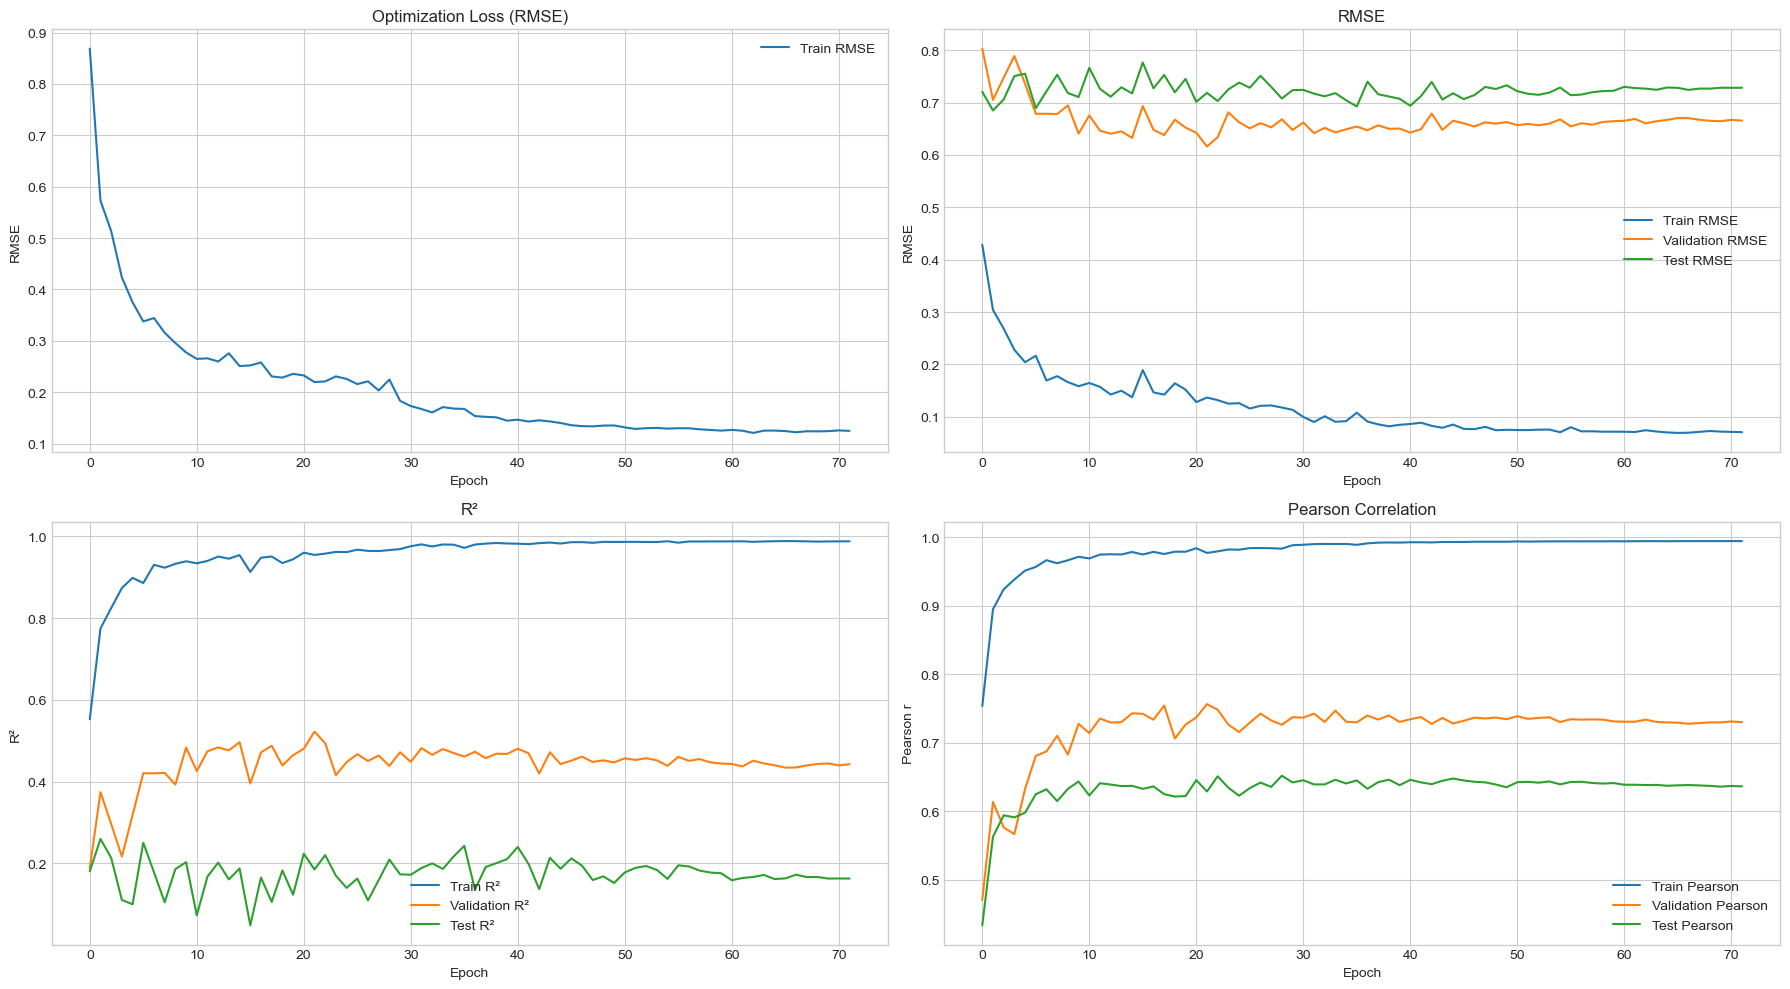

,train_loss,train_rmse,train_r2,train_pearson,val_rmse,val_r2,val_pearson,test_rmse,test_r2,test_pearson
67,0.1241,0.0712,0.9877,0.9945,0.6674,0.4395,0.7287,0.7267,0.1664,0.6377
68,0.1239,0.0728,0.9871,0.9946,0.6652,0.4430,0.7298,0.7267,0.1666,0.6370
69,0.1242,0.0717,0.9875,0.9946,0.6644,0.4444,0.7297,0.7284,0.1627,0.6359
70,0.1257,0.0711,0.9877,0.9946,0.6672,0.4397,0.7311,0.7283,0.1630,0.6369
71,0.1249,0.0707,0.9878,0.9946,0.6656,0.4424,0.7301,0.7283,0.1628,0.6363


In [40]:
# Train with the fixed tuned configuration loaded earlier.
selected_model_config = normalize_model_config()
selected_training_config = normalize_training_config()
config_source = f"fixed best hyperparameters from {HPARAMS_PATH.name} with batch_size={selected_training_config['batch_size']}"

print_banner('Final training run')
print(f'Training with {config_source}.')
display(
    pd.DataFrame(
        [
            {'group': 'model', 'name': key, 'value': value}
            for key, value in selected_model_config.items()
        ]
        + [
            {'group': 'training', 'name': key, 'value': value}
            for key, value in selected_training_config.items()
        ]
        + [
            {'group': 'data', 'name': 'original_train_graphs', 'value': len(ORIGINAL_TRAIN_GRAPHS)},
            {'group': 'data', 'name': 'appended_digress_graphs', 'value': len(DIGRESS_PSEUDOLABELED_GRAPHS)},
            {'group': 'data', 'name': 'augmented_train_graphs', 'value': len(GRAPH_CACHE_CONTENT['train'])},
        ]
    )
)

# Rebuild loaders using the fixed batch size from the second-run configuration.
train_loader, val_loader, test_loader = build_data_loaders(selected_training_config['batch_size'])
model = instantiate_model(selected_model_config)
training_result = fit_regressor(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    model_config=selected_model_config,
    training_config=selected_training_config,
    checkpoint_path=CHECKPOINT_PATH,
    history_path=HISTORY_PATH,
    verbose=True,
)

history = training_result['history']
history_frame = history_to_frame(history)
loss_name = training_result['loss_name']

display_key_values(
    'Best validation checkpoint',
    {
        'Optimization loss': loss_name.upper(),
        'Best epoch': training_result['best_epoch'],
        'Validation RMSE': round(training_result['best_val_rmse'], 4),
        'Validation R²': round(training_result['best_val_r2'], 4),
        'Validation Pearson': round(training_result['best_val_pearson'], 4),
        'Checkpoint path': CHECKPOINT_PATH,
        'History path': HISTORY_PATH,
    },
)

plot_training_history(history_frame, loss_name=loss_name)
display(history_frame.tail().round(4))

## Prediction Cell

Run the next cell after training to reload the saved checkpoint and generate predictions on the test set.

The checkpoint stores the model architecture and normalization settings needed to rebuild the trained regressor. The resulting table contains the PDB identifier, SMILES string, experimental $pIC50$, predicted $pIC50$, and absolute error for each test molecule.

In [41]:
# Reload the best saved model and recover the batch size used for inference.
checkpoint, prediction_model = load_trained_model(CHECKPOINT_PATH)
checkpoint_config = checkpoint['config']
prediction_training_config = normalize_training_config(
    {
        'batch_size': checkpoint_config.get('batch_size', BASE_TRAINING_CONFIG['batch_size']),
    }
)

_, _, prediction_test_loader = build_data_loaders(prediction_training_config['batch_size'])
test_results = evaluate_regression(prediction_model, prediction_test_loader)

predictions_frame = pd.DataFrame(
    {
        'PDB_ID': test_results['pdb_id'],
        'SMILES': test_results['smiles'],
        'pIC50_real': test_results['targets'],
        'pIC50_predicted': test_results['predictions'],
    }
)
predictions_frame['absolute_error'] = (predictions_frame['pIC50_real'] - predictions_frame['pIC50_predicted']).abs()
predictions_frame.to_csv(PREDICTIONS_PATH, index=False)

display_key_values(
    'Prediction summary',
    {
        'Checkpoint path': CHECKPOINT_PATH,
        'Prediction batch size': prediction_training_config['batch_size'],
        'Test RMSE': round(test_results['rmse'], 4),
        'Test R²': round(test_results['r2'], 4),
        'Test Pearson': round(test_results['pearson'], 4),
        'Predictions CSV': PREDICTIONS_PATH,
    },
)

display(predictions_frame.head().round(4))


Prediction summary


,value
Checkpoint path,C:\Users\xaviv\URV\.MESIIA\TFM\repo\DiGressMPr...
Prediction batch size,128
Test RMSE,0.7186
Test R²,0.185
Test Pearson,0.6288
Predictions CSV,C:\Users\xaviv\URV\.MESIIA\TFM\repo\DiGressMPr...


,PDB_ID,SMILES,pIC50_real,pIC50_predicted,absolute_error
0,5RH3,Cc1ccncc1NC(=O)[C@H](C)c2cccc(c2)Cl,4.5817,4.3313,0.2504
1,7GBV,Cc1ccncc1NC(=O)C(C)(C)c2cccc(c2)Cl,4.0135,4.4997,0.4862
2,7GBX,c1ccc2c(c1)ncn2NC(=O)Cc3cccc(c3)Cl,5.0807,5.0219,0.0589
3,7GCV,Cc1ccncc1NC(=O)Cc2cc(cc(c2)Cl)O[C@@H]3CC(=O)N3,5.4402,4.3216,1.1186
4,7GD5,CN(C)c1ccc(cc1)N(Cc2ccsc2)C(=O)Cn3c4ccccc4nn3,5.7462,5.1822,0.5640


## Test Metrics and ROC/AUC

This section summarizes the regression quality on the test set and then derives a binary activity task from the continuous predictions.

Reported metrics:

- Pearson correlation coefficient
- RMSE
- $R^2$
- ROC AUC using the activity threshold `pIC50 >= 6.0`

The ROC plot is helpful for checking whether higher predicted $pIC50$ values also rank actives ahead of inactives, even though the model was trained as a regressor.


Test-set metrics


,metric,value
0,Pearson,0.6288
1,RMSE,0.7186
2,R2,0.1850
3,ROC_AUC,0.7429



Activity class balance used for ROC/AUC


,class_label,count
0,inactive,35
1,active,29


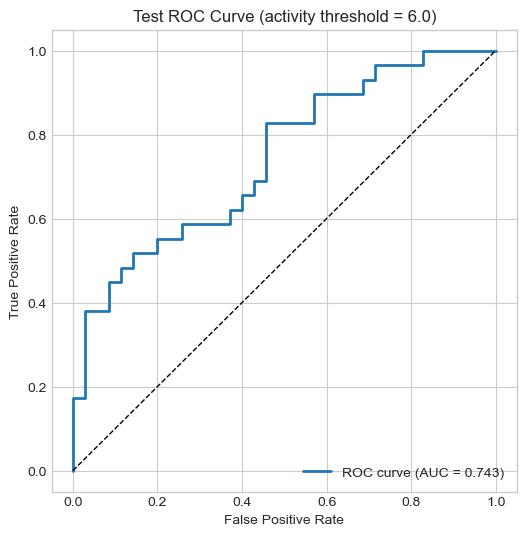

In [42]:
# Reuse the predictions generated in the previous cell.
y_true = test_results['targets']
y_pred = test_results['predictions']

pearson_value = test_results['pearson']
rmse_value = test_results['rmse']
r2_value = test_results['r2']

# Convert the continuous target into a binary activity label for ROC/AUC.
binary_true = (y_true >= ACTIVE_THRESHOLD).astype(int)
if np.unique(binary_true).size < 2:
    raise ValueError('ROC/AUC requires both classes to be present in the test set for the chosen threshold.')

fpr, tpr, _ = roc_curve(binary_true, y_pred)
auc_value = roc_auc_score(binary_true, y_pred)

metrics_frame = pd.DataFrame(
    {
        'metric': ['Pearson', 'RMSE', 'R2', 'ROC_AUC'],
        'value': [pearson_value, rmse_value, r2_value, auc_value],
    }
)
class_balance_frame = pd.DataFrame(
    {
        'class_label': ['inactive', 'active'],
        'count': [(binary_true == 0).sum(), (binary_true == 1).sum()],
    }
)

print_banner('Test-set metrics')
display(metrics_frame.round(4))
print_banner('Activity class balance used for ROC/AUC')
display(class_balance_frame)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc_value:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='black', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'Test ROC Curve (activity threshold = {ACTIVE_THRESHOLD:.1f})')
plt.legend(loc='lower right')
plt.show()

## Predicted vs Real pIC50

The final view compares predicted and experimental values directly. Points close to the diagonal indicate good agreement, while large deviations highlight molecules the model struggles with.

Alongside the scatter plot, the code also lists the worst absolute errors so the hardest test examples can be inspected first.

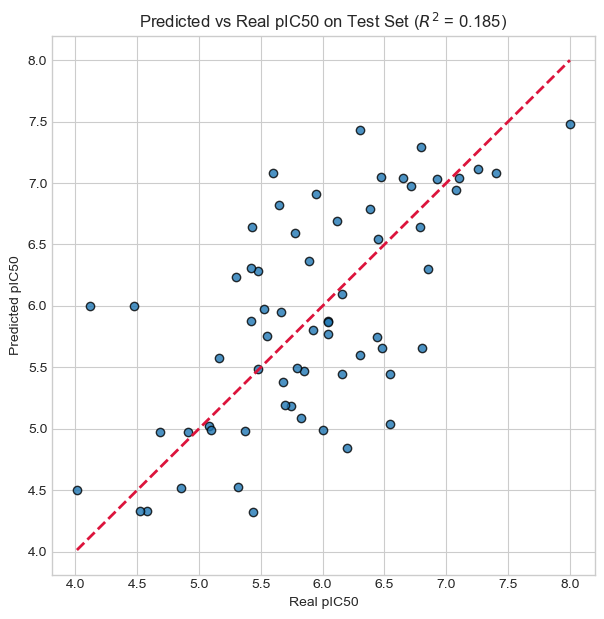


Largest test-set errors


,PDB_ID,SMILES,pIC50_real,pIC50_predicted,absolute_error,residual
9,7GEZ,CC(=O)N1CCN(CC1)CC(=O)Nc2cncc3c2cccc3,4.1216,5.9974,1.8758,1.8758
16,7GG8,c1cc(cc(c1)Cl)CC(=O)N2CCCc3c2cncc3N,4.4754,5.9994,1.5240,1.5240
13,7GFM,CN(C)c1ccc(cc1)N(Cc2ccsc2)C(=O)Cc3cncc4c3cccc4,6.5457,5.0423,1.5034,-1.5034
41,7GM0,Cn1c2c(cncc2NC(=O)[C@@H]3CN(Cc4c3cc(cc4)Cl)S(=...,5.5968,7.0794,1.4826,1.4826
7,7GEB,Cc1ccncc1NC(=O)CN2CCN(CC2)C(=O)C,6.1952,4.8408,1.3544,-1.3544
53,7GNE,C[C@@]1(CNS(=O)(=O)c2c1cc(cc2)Cl)C(=O)Nc3cncc4...,5.4291,6.6455,1.2164,1.2164
37,7GKX,COCCN1Cc2ccc(cc2[C@@H](C1)C(=O)Nc3cncc4c3cccc4)Cl,5.6450,6.8235,1.1785,1.1785
30,7GJM,C[C@H]1COc2ccc(cc2[C@@H]1C(=O)Nc3cncc4c3cccc4)Cl,6.8048,5.6537,1.1511,-1.1511
62,8UEH,c1ccc(cc1)CCNC(=O)C[C@H](Cc2ccc(cc2)F)NC(=O)[C...,6.3010,7.4304,1.1293,1.1293
3,7GCV,Cc1ccncc1NC(=O)Cc2cc(cc(c2)Cl)O[C@@H]3CC(=O)N3,5.4402,4.3216,1.1186,-1.1186


In [43]:
# Plot predicted versus experimental pIC50 values.
comparison_frame = predictions_frame.copy()
comparison_frame['residual'] = comparison_frame['pIC50_predicted'] - comparison_frame['pIC50_real']
comparison_frame['absolute_error'] = comparison_frame['residual'].abs()

plt.figure(figsize=(7, 7))
plt.scatter(y_true, y_pred, alpha=0.8, edgecolor='black')

min_value = min(y_true.min(), y_pred.min())
max_value = max(y_true.max(), y_pred.max())
plt.plot([min_value, max_value], [min_value, max_value], linestyle='--', color='crimson', linewidth=2)

plt.xlabel('Real pIC50')
plt.ylabel('Predicted pIC50')
plt.title(f'Predicted vs Real pIC50 on Test Set ($R^2$ = {r2_value:.3f})')
plt.xlim(min_value - 0.2, max_value + 0.2)
plt.ylim(min_value - 0.2, max_value + 0.2)
plt.show()

print_banner('Largest test-set errors')
display(
    comparison_frame.sort_values('absolute_error', ascending=False).head(10).round(4)
)